In [30]:
import sys
from data_loader import load_nbbosz
from imbalance import prepare_features
from plotting import plot_qimbal_dist
from forecast import (
    filter_mid_change_events, compute_fcastdir, 
    confusion_matrix_df, f1_per_class, macro_f1, 
    optimize_cutoff, eval_cutoffs,
) 
 

import pandas as pd

# 1. Process data and compute
- midpx
- qimbal
- nextmid 
- ttnextmid 
- label direction of next mid price change 

In [ ]:
df_raw = load_nbbosz("2025-04-01", data_dir="../data")
# compute midpx, qimbal, nextmid, ttnextmid, and nextdir
df = prepare_features(df_raw, delta_t_ms=200)  
print(df.shape) 
print(df.dtypes)
print(df["sym"].value_counts().sort_index())
# check ts
print(df["tstamp"].min(), df["tstamp"].max())
# check null
print(df[["nextbid", "nextask"]].isnull().sum())

(1146879, 16)
date                    object
sym                     object
tstamp          datetime64[ns]
bidpx                  float64
askpx                  float64
bidsz                  float64
asksz                  float64
nextbidstamp    datetime64[ns]
nextbid                float64
nextaskstamp    datetime64[ns]
nextask                float64
midpx                  float64
qimbal                 float64
nextmid                float64
ttnextmid              float64
nextdir                  int64
dtype: object
sym
AAL      86252
BAC     200089
DUK      31747
HUM       5732
TSLA    823059
Name: count, dtype: int64
2025-04-01 09:30:00.000789 2025-04-01 16:00:01.000884
nextbid    37
nextask    80
dtype: int64


## 1.2 Descriptive stats

In [14]:
stats_cols = ["qimbal", "nextdir", "ttnextmid"]

for sym, g in df.groupby("sym"):
    print(f"\n{'='*40}\n{sym}")
    print(g[stats_cols].describe().round(4))


AAL
           qimbal     nextdir    ttnextmid
count  86252.0000  86252.0000   86230.0000
mean       0.0111     -0.0005   27848.1632
std        0.4781      0.3756   37272.7265
min       -0.9996     -1.0000       0.0000
25%       -0.3203      0.0000    2267.7003
50%        0.0163      0.0000   13438.2460
75%        0.3432      0.0000   38909.2078
max        0.9992      1.0000  301168.4230

BAC
            qimbal      nextdir    ttnextmid
count  200089.0000  200089.0000  200088.0000
mean        0.0322       0.0038    5921.1538
std         0.5649       0.4473    8778.2609
min        -0.9992      -1.0000       0.0000
25%        -0.4373       0.0000     419.0478
50%         0.0518       0.0000    2452.1655
75%         0.5064       0.0000    7577.0832
max         0.9997       1.0000   78663.3710

DUK
           qimbal     nextdir   ttnextmid
count  31747.0000  31747.0000  31746.0000
mean      -0.0663      0.0002   2326.5509
std        0.4249      0.7550   5905.8179
min       -0.9978     -1.

In [15]:
for sym, g in df.groupby("sym"):                                                                                                                   
    counts = g["nextdir"].value_counts().sort_index()                                                                                              
    pct = (counts / len(g) * 100).round(1)                                                                                                         
    print(f"{sym}: {counts.to_dict()}  pct: {pct.to_dict()}")     

AAL: {-1: 6106, 0: 74082, 1: 6064}  pct: {-1: 7.1, 0: 85.9, 1: 7.0}
BAC: {-1: 19639, 0: 160047, 1: 20403}  pct: {-1: 9.8, 0: 80.0, 1: 10.2}
DUK: {-1: 9044, 0: 13652, 1: 9051}  pct: {-1: 28.5, 0: 43.0, 1: 28.5}
HUM: {-1: 1263, 0: 3076, 1: 1393}  pct: {-1: 22.0, 0: 53.7, 1: 24.3}
TSLA: {-1: 365096, 0: 85270, 1: 372693}  pct: {-1: 44.4, 0: 10.4, 1: 45.3}


## 1.3 Plot aal, bac, duk, tsla

/var/folders/07/93fsqcys31jd88vb8lkpz_gc0000gn/T/ipykernel_33128/2058922403.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


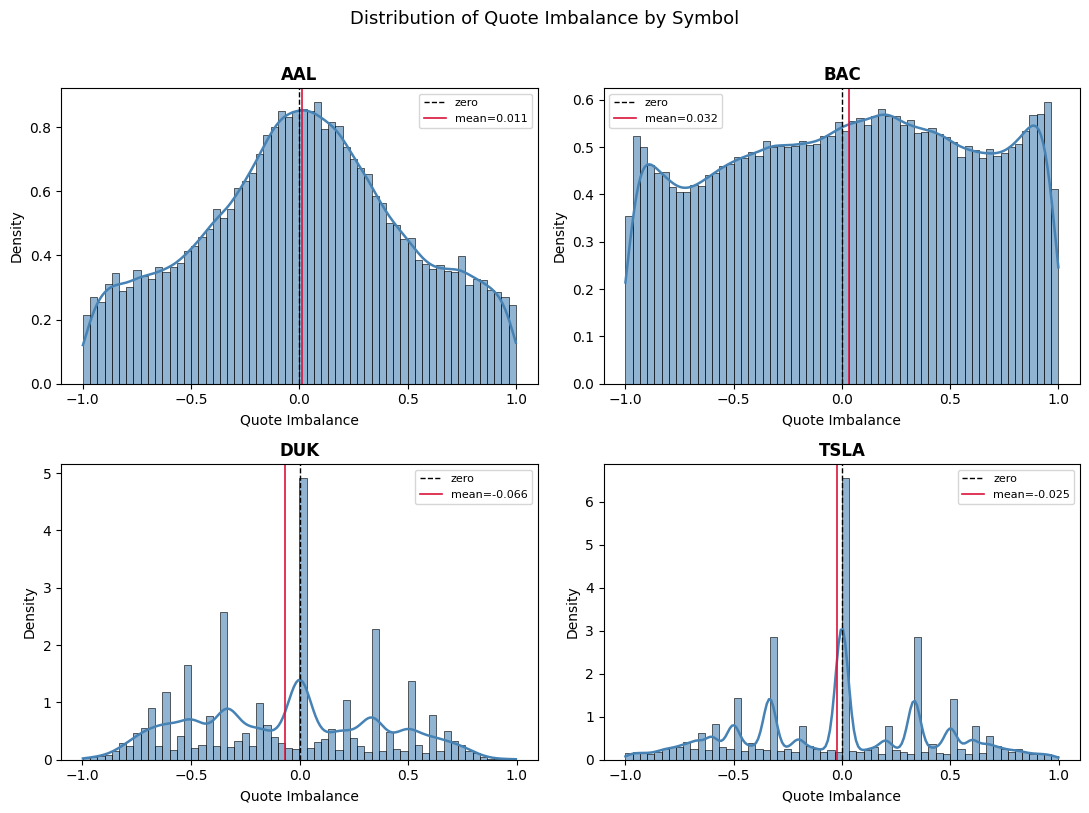

In [19]:
symbols_to_plot = ["AAL", "BAC", "DUK", "TSLA"]
fig = plot_qimbal_dist(
    df,
    symbols=symbols_to_plot,
    save_path="../figures/task1_qimbal_dist.png",
)
fig.show()

# 2. Build and segmented reg model on training data

In [22]:
df_train = prepare_features(load_nbbosz("2025-04-01", data_dir="../data"))
df_filtered = filter_mid_change_events(df_train) 
len(df_train), len(df_filtered)

(1146879, 664370)

## 2.1 F1 score table

In [ ]:
CUTOFFS = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
f1_table, l_star = optimize_cutoff(df_filtered, cutoffs=CUTOFFS)
print(f1_table.round(4).to_string())

cutoff    0.60    0.70    0.80    0.85    0.90    0.95
sym                                                   
AAL     0.5893  0.6078  0.5952  0.5702  0.5249  0.4333
BAC     0.5357  0.5628  0.5706  0.5577  0.5185  0.4342
DUK     0.3845  0.3290  0.2727  0.2514  0.2419  0.2339
HUM     0.4239  0.3982  0.3470  0.3147  0.3086  0.3045
TSLA    0.2330  0.1719  0.1355  0.1185  0.1084  0.0965


## 2.2 Confusion Matrix

In [24]:
for sym, g in df_filtered.groupby("sym"): 
    L = l_star[sym] 
    g_f = compute_fcastdir(g, L) 
    cm = confusion_matrix_df(g_f["nextdir"], g_f["fcastdir"]) 
    f1s = f1_per_class(cm) 
    mf1 = macro_f1(g_f["nextdir"], g_f["fcastdir"]) 
 
    print(f"\n{'═'*48}")
    print(f"  {sym}  |  L* = {L}  |  Macro F1 = {mf1:.4f}") 
    print(f"{'═'*48}") 
    print(f"  Confusion matrix (rows=actual, cols=predicted):") 
    print(cm.to_string()); print() 
    print(f"  Per-class F1:  -1={f1s[-1]:.4f}   0={f1s[0]:.4f}   +1={f1s[1]:.4f}")


════════════════════════════════════════════════
  AAL  |  L* = 0.7  |  Macro F1 = 0.6078
════════════════════════════════════════════════
  Confusion matrix (rows=actual, cols=predicted):
predicted    -1      0     1
actual                      
-1         2900   2773   270
 0         4669  64329  4219
 1           21   2489  3414

  Per-class F1:  -1=0.4286   0=0.9009   +1=0.4938

════════════════════════════════════════════════
  BAC  |  L* = 0.8  |  Macro F1 = 0.5706
════════════════════════════════════════════════
  Confusion matrix (rows=actual, cols=predicted):
predicted    -1       0      1
actual                        
-1         7277   10591    170
 0         9740  134495  11447
 1          162   10199   8405

  Per-class F1:  -1=0.4133   0=0.8650   +1=0.4334

════════════════════════════════════════════════
  DUK  |  L* = 0.6  |  Macro F1 = 0.3845
════════════════════════════════════════════════
  Confusion matrix (rows=actual, cols=predicted):
predicted   -1     0    1
ac

In [25]:
df_test02 = prepare_features(load_nbbosz("2025-04-02", data_dir="../data"))                                                                                                           
df_test02_f = filter_mid_change_events(df_test02)                                                                                                                                     
                                                                                                                                                                                    
oos_f1_02 = eval_cutoffs(df_test02_f, l_star)                                                                                                                                         
                                                                                                                                                                                    
print("In-sample vs OOS comparison  (train=04-01 → test=04-02)\n")                                                                                                                    
compare = pd.DataFrame({                                                                                                                                                            
    "L_star":       l_star,                                                                                                                                                           
    "IS_F1(04-01)": f1_table.max(axis=1).round(4),                                                                                                                                  
    "OOS_F1(04-02)": oos_f1_02.round(4),                                                                                                                                              
})
print(compare.to_string())   

In-sample vs OOS comparison  (train=04-01 → test=04-02)

      L_star  IS_F1(04-01)  OOS_F1(04-02)
AAL      0.7        0.6078         0.6741
BAC      0.8        0.5706         0.6077
DUK      0.6        0.3845         0.3877
HUM      0.6        0.4239         0.4222
TSLA     0.6        0.2330         0.2407


In [26]:
def run_train_test(train_date: str, test_date: str, data_dir: str = "../data"):                                                                                                       
    """Return (l_star, f1_table, oos_f1) for a train/test date pair."""                                                                                                               
    df_tr = filter_mid_change_events(prepare_features(load_nbbosz(train_date, data_dir)))                                                                                             
    df_te = filter_mid_change_events(prepare_features(load_nbbosz(test_date, data_dir)))                                                                                              
    f1_table, l_star = optimize_cutoff(df_tr)                                                                                                                                         
    oos_f1 = eval_cutoffs(df_te, l_star)                                                                                                                                              
    return l_star, f1_table, oos_f1      

In [27]:
pairs = [("2025-04-01", "2025-04-02"),                                                                                                                                                
        ("2025-04-02", "2025-04-03"),                                                                                                                                                
        ("2025-04-03", "2025-04-04")]                                                                                                                                                
                                                                                                                                                                                    
all_results = {}                                                                                                                                                                      
for train_date, test_date in pairs:
    l_star_i, f1_tbl_i, oos_f1_i = run_train_test(train_date, test_date)                                                                                                              
    all_results[(train_date, test_date)] = {                                                                                                                                          
        "l_star":   l_star_i,
        "is_f1":    f1_tbl_i.max(axis=1),                                                                                                                                             
        "oos_f1":   oos_f1_i,                                                                                                                                                         
    }
    print(f"\n{'─'*55}")                                                                                                                                                              
    print(f"  Train: {train_date}   →   Test: {test_date}")                                                                                                                           
    print(f"{'─'*55}")
    summary = pd.DataFrame({                                                                                                                                                          
        "L_star":  l_star_i,                                                                                                                                                          
        "IS_F1":   f1_tbl_i.max(axis=1).round(4),
        "OOS_F1":  oos_f1_i.round(4),                                                                                                                                                 
    })                                                                                                                                                                                
    print(summary.to_string())


───────────────────────────────────────────────────────
  Train: 2025-04-01   →   Test: 2025-04-02
───────────────────────────────────────────────────────
      L_star   IS_F1  OOS_F1
AAL      0.7  0.6078  0.6741
BAC      0.8  0.5706  0.6077
DUK      0.6  0.3845  0.3877
HUM      0.6  0.4239  0.4222
TSLA     0.6  0.2330  0.2407

───────────────────────────────────────────────────────
  Train: 2025-04-02   →   Test: 2025-04-03
───────────────────────────────────────────────────────
      L_star   IS_F1  OOS_F1
AAL      0.7  0.6741  0.5657
BAC      0.7  0.6160  0.5365
DUK      0.6  0.3877  0.3831
HUM      0.6  0.4222  0.4093
TSLA     0.6  0.2407  0.2637

───────────────────────────────────────────────────────
  Train: 2025-04-03   →   Test: 2025-04-04
───────────────────────────────────────────────────────
      L_star   IS_F1  OOS_F1
AAL      0.8  0.5673  0.5393
BAC      0.6  0.5399  0.5701
DUK      0.6  0.3831  0.3628
HUM      0.6  0.4093  0.4024
TSLA     0.6  0.2637  0.2528


In [28]:
l_star_df = pd.DataFrame(                                                                                                                                                             
    {train: res["l_star"] for (train, _), res in all_results.items()}
)                                                                                                                                                                                     
l_star_df.columns = [p[0] for p in pairs]                                                                                                                                           
l_star_df.index.name = "sym"                                                                                                                                                          
l_star_df.columns.name = "train_date"                                                                                                                                               
                                                                                                                                                                                    
print("Optimal L* by symbol across training dates\n")                                                                                                                               
print(l_star_df.to_string())     

Optimal L* by symbol across training dates

train_date  2025-04-01  2025-04-02  2025-04-03
sym                                           
AAL                0.7         0.7         0.8
BAC                0.8         0.7         0.6
DUK                0.6         0.6         0.6
HUM                0.6         0.6         0.6
TSLA               0.6         0.6         0.6


In [29]:
oos_df = pd.DataFrame(                                                                                                                                                                
    {f"{tr}→{te}": res["oos_f1"] for (tr, te), res in all_results.items()}                                                                                                            
).round(4)                                                                                                                                                                            
oos_df.index.name = "sym"                                                                                                                                                             
                                                                                                                                                                                    
print("OOS macro F1 by symbol across test dates\n")                                                                                                                                   
print(oos_df.to_string())

OOS macro F1 by symbol across test dates

      2025-04-01→2025-04-02  2025-04-02→2025-04-03  2025-04-03→2025-04-04
sym                                                                      
AAL                  0.6741                 0.5657                 0.5393
BAC                  0.6077                 0.5365                 0.5701
DUK                  0.3877                 0.3831                 0.3628
HUM                  0.4222                 0.4093                 0.4024
TSLA                 0.2407                 0.2637                 0.2528
